# Beer and Hotwings: Permutation Testing

This notebook applies permutation testing to the *Beer and Hotwings* dataset. This dataset was generated at Williams Bar in an uptown area of Minneapilos. The experimenter surveyed customers about thier consumtion of hot wings and beer over the course of several hours. The data includes:
- Hotwings: number of hotwings customer ate
- Beer: total ounces of beer drank
- Gender: male or female

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import random

# Settings
plt.style.use("ggplot")

### Data Exploration
Summary statistics and graphs.

In [126]:
# Read data
beer_wings = pd.read_csv("../Data/beerwings.csv")

print(f"Total number of observations: {len(beer_wings)}")
print(beer_wings.head())

Total number of observations: 30
   ID  Hotwings  Beer Gender
0   1         4    24      F
1   2         5     0      F
2   3         5    12      F
3   4         6    12      F
4   5         7    12      F


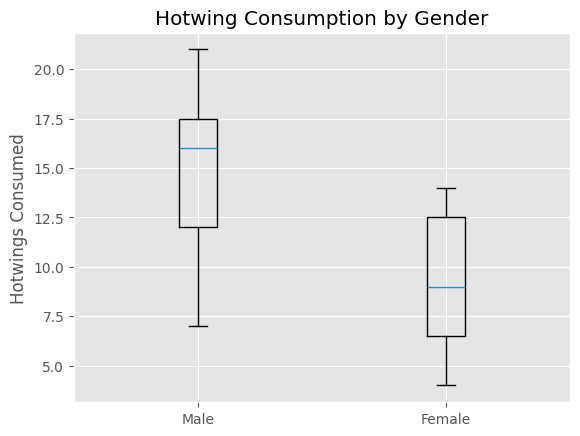

In [127]:
# Create the box plot
fig, ax = plt.subplots()
ax.boxplot(
    [
        beer_wings[beer_wings["Gender"] == "M"]["Hotwings"],
        beer_wings[beer_wings["Gender"] == "F"]["Hotwings"]
    ]
)

ax.set_title("Hotwing Consumption by Gender")
ax.set_xticklabels(["Male", "Female"])
ax.set_ylabel("Hotwings Consumed")
plt.show()

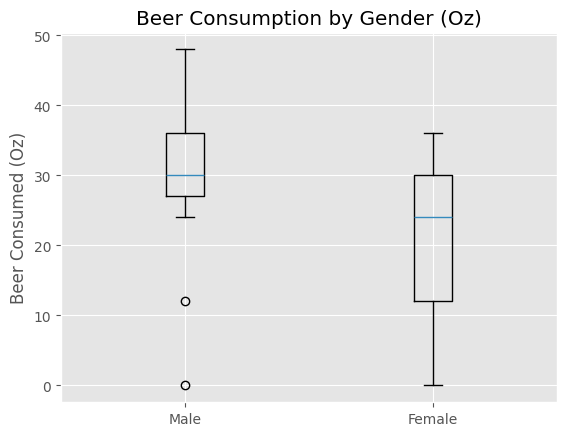

In [128]:
# Create the box plot
fig, ax = plt.subplots()
ax.boxplot(
    [
        beer_wings[beer_wings["Gender"] == "M"]["Beer"],
        beer_wings[beer_wings["Gender"] == "F"]["Beer"]
    ]
)

ax.set_title("Beer Consumption by Gender (Oz)")
ax.set_xticklabels(["Male", "Female"])
ax.set_ylabel("Beer Consumed (Oz)")
plt.show()

In [130]:
# Sample statistics per gender
male = beer_wings[beer_wings["Gender"] == "M"]
female = beer_wings[beer_wings["Gender"] == "F"]

print("Male Statistics =========")
print(f"Mean oz of beer: {male["Beer"].mean():.1f}")
print(f"Std. of beer (oz): {male["Beer"].std():.2f}")
print(f"Mean number of hotwings: {male["Hotwings"].mean():.2f}")
print(f"Std. number of hotwings: {male["Hotwings"].std():.2f}")

print("Female Statistics =========")
print(f"Mean oz of beer: {female["Beer"].mean():.1f}")
print(f"Std. of beer (oz): {female["Beer"].std():.2f}")
print(f"Mean number of hotwings: {female["Hotwings"].mean():.2f}")
print(f"Std. number of hotwings: {female["Hotwings"].std():.2f}")

Male Statistics =========
Mean oz of beer: 30.4
Std. of beer (oz): 12.10
Mean number of hotwings: 14.53
Std. number of hotwings: 4.50
Female Statistics =========
Mean oz of beer: 22.0
Std. of beer (oz): 10.31
Mean number of hotwings: 9.33
Std. number of hotwings: 3.56


As we can see from the sample statistics above, on average, males ate more wings and drank more beer than females. And in both cases, the standard deviation of the male samples are greater than the female samples.

In [131]:
mean_diff_hotwings = abs(male["Hotwings"].mean() - female["Hotwings"].mean())
mean_diff_beer = abs(male["Beer"].mean() - female["Beer"].mean())

print(f"Difference in hotwing means: {mean_diff_hotwings:.2f}")
print(f"Difference in mean beer (oz): {mean_diff_beer:.2f}")

Difference in hotwing means: 5.20
Difference in mean beer (oz): 8.40


### Creating Hypotheses: Hotwings
What we want to know is that can the difference in the mean hotwing and beer consumption between males and females be explained by chance alone, or is there an actual relationship between gender and consumption.

Given $\mu_M$ is the mean number of hotwings consumed by males and $\mu_F$ is the mean number of hotwings consumed by females:

$H_0: \mu_M=\mu_F$<br>
$H_A: \mu_M>\mu_F$

Our test statistic and observed test statistic are:

$T=\bar{X}_M-\bar{X}_F$<br>
$t=5.20$

In [132]:
# Permutation samples
N = 100_000 # Permutations
S = 15      # Sample size

hotwings = beer_wings["Hotwings"]

perm_t_stats = []
for n in range(N):
    sample_m = hotwings.sample(n=S)
    sample_f = hotwings.drop(sample_m.index)
    
    perm_t_stats.append(sample_m.mean() - sample_f.mean())

# Compute the P-value
p = (sum(1 if t > mean_diff_hotwings else 0 for t in perm_t_stats) + 1) / (N + 1)
print(f"P-Value: {p}")

P-Value: 0.0006999930000699993


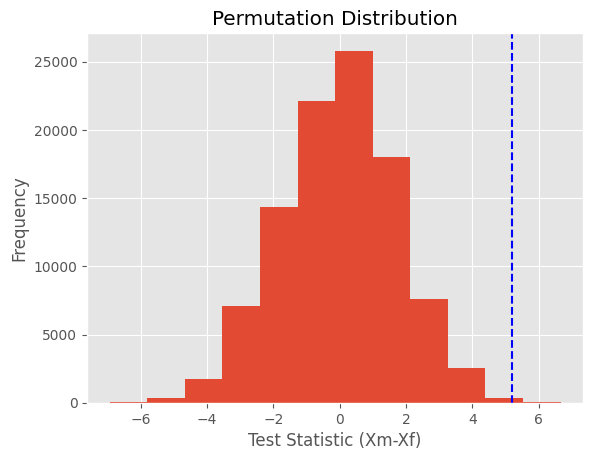

In [133]:
# Plot the permutation distribution
plt.hist(perm_t_stats, bins=12)
plt.axvline(x=mean_diff_hotwings, color="blue", linestyle="--")
plt.title("Permutation Distribution")
plt.ylabel("Frequency")
plt.xlabel("Test Statistic (Xm-Xf)")
plt.show()